In [29]:
import sys 
from math import floor, ceil

sys.path.append('../src')
import sys
print(sys.executable)
from main import DataPipeline

pipeline = DataPipeline()
df = pipeline.pre_process_data()
df_engineered = pipeline.feature_engineering(df)
df_engineered = df_engineered.drop(columns=['anomalous_day_flag'])
# df_engineered.columns
print(df_engineered['recovery_score_shift'].isnull().sum())

/Users/jordanpickles/opt/miniconda3/envs/whoop-pipeline/bin/python
1


# 1.1 Splitting the data
Here a 70/30 split in a temporally ascending order will be taken with a 7 day washout period between these splits to ensure there is data leakage with the 7 day rolling averages.
70:30 split used in this time series dataset to capture any seasonal trends within the data

In [30]:
row_count = len(df_engineered)
row_count_washout_removal = row_count - 7
train_upper_bound = floor(row_count_washout_removal * 0.7)
test_lower_bound = train_upper_bound + 7 
df_engineered = df_engineered.sort_values('date_local').reset_index(drop=True)

train = df_engineered.iloc[7:train_upper_bound]
test = df_engineered.iloc[test_lower_bound:-1]

print(f"Train - Start Date: {train['date_local'].min()} | End Date: {train['date_local'].max()} | Number of Rows: {len(train)} | % of Total Rows: {len(train) / row_count}")
print(f"Test - Start Date: {test['date_local'].min()} | End Date: {test['date_local'].max()} | Number of Rows: {len(test)} | % of Total Rows: {len(test) / row_count}")


Train - Start Date: 2024-01-08 06:26:25.219000 | End Date: 2025-09-11 03:42:40.847000 | Number of Rows: 606 | % of Total Rows: 0.6862967157417894
Test - Start Date: 2025-09-20 08:01:07.809000 | End Date: 2026-06-08 06:05:57.868000 | Number of Rows: 262 | % of Total Rows: 0.29671574178935445


# 1.2 Split out Features and Label
Labels: Recovery Score Shift (-1 day)

In [31]:
features = [col for col in train.columns if col not in ['recovery_score_shift', 'date_local']]
label = [col for col in train.columns if col not in features and col not in 'date_local']

X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]


print(f"Features: {features}")
print(f"Label: {label}")


Features: ['recovery_score', 'resting_heart_rate', 'hrv_rmssd_milli', 'skin_temp_celsius', 'sleep_efficiency_percentage', 'sleep_consistency_percentage', 'sleep_performance_percentage', 'respiratory_rate', 'sleep_cycle_count', 'disturbance_count', 'sleep_needed_baseline_milli', 'sleep_needed_need_from_recent_strain_milli', 'cycle_strain', 'cycle_avg_heart_rate', 'cycle_kilojoule', 'total_in_bed_time_hours', 'total_rem_sleep_time_hours', 'total_sleep_time_hours', 'hrv_rmssd_milli_rolling_avg_7', 'resting_heart_rate_rolling_avg_7', 'cycle_strain_rolling_avg_7', 'day_of_week', 'sleep_start_local_decimal', 'sleep_end_local_decimal']
Label: ['recovery_score_shift']


# 2.1 Baseline Linear Regression Plots

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.2f}")
print(f"The Linear Model explains {r2_score(y_test, y_pred_lr)*100:.2f}% of the variance in tomorrows Recovery Score")

MAE: 13.09
RMSE: 16.52
R2: 0.32
The Linear Model explains 31.98% of the variance in tomorrows Recovery Score


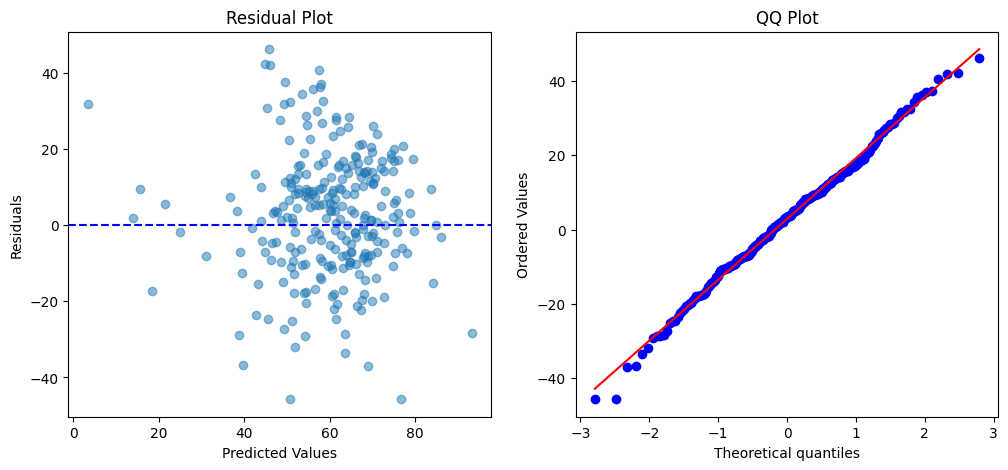

In [33]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import probplot


residuals = np.subtract(np.array(y_test), y_pred_lr).astype(float).flatten() # difference between actual and predicted

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.scatter(y_pred_lr, residuals, alpha=0.5)
ax1.axhline(y=0, color='b', linestyle='--')
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residual Plot')

# QQ plot
stats.probplot(residuals, plot=ax2)
ax2.set_title('QQ Plot')



plt.show()

- QQ plot shows that residuals are approximately normally distributed, meaning linear assumptions partially hold
- However, the residual plot shows increasing variance in residuals as predicted values increase, indicating heteroscedasticity. The linear model struggles disproportionately when predicting higher recovery scores
- Combined with weak linear correlations across the majority of features, this suggests the relationships are non-linear and potentially conditional on feature interactions (e.g. Sleep Time in combination with resting heart rate etc)
- This justifies the use of a tree-based ensemble method (XGBoost) which makes no assumptions about error distribution, handles non-linear relationships natively, and captures feature interactions through sequential tree building

## 2.1.2 Lasso Regression


In [35]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1))
])

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")
print(f"R2: {r2_score(y_test, y_pred_lasso):.2f}")

MAE: 12.90
RMSE: 16.30
R2: 0.34


# 2.2 XGBoost Model

## 2.2.1 Baseline Model

In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"R2: {r2_score(y_test, y_pred_xgb):.2f}")
print(f"The XGBoost model explains {r2_score(y_test, y_pred_xgb)*100:.2f}% of the variance in tomorrows Recovery Score")

MAE: 12.78
RMSE: 16.03
R2: 0.36
The XGBoost model explains 35.97% of the variance in tomorrows Recovery Score


The metrics for the baseline xgboost model outperform the linear regression baseline and validate the use of this model. With the xgboost model baseline explaining an extra 5% of the variance in tomorrows recovery score


## 2.2.2 Model Optimisation

In [36]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(2,6),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2)
}


tscv = TimeSeriesSplit(n_splits=5) # Number of folds, split temporally to ensure it always trains on past folds and validates on future ones

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'colsample_bytree': np.float64(0.8010716092915446), 'learning_rate': np.float64(0.02029575024999787), 'max_depth': 2, 'n_estimators': 323, 'reg_alpha': np.float64(0.9082658859666537), 'reg_lambda': np.float64(0.47912378133394484), 'subsample': np.float64(0.6579579488364892)}


In [37]:
best_xgb = XGBRegressor(**search.best_params_, random_state=42)

best_xgb.fit(X_train, y_train)
y_pred_best = best_xgb.predict(X_test)


print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R2: {r2_score(y_test, y_pred_best):.2f}")

MAE: 12.45
RMSE: 15.69
R2: 0.39


# 2.2.3 Model Comparison

Four models were evaluated on a temporal 70/30 train/test split with a 7-day washout period to prevent data leakage from rolling features.

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 13.09 | 16.52 | 0.32 |
| LASSO | 12.92 | 16.35 | 0.33 |
| XGBoost (default) | 12.78 | 16.03 | 0.36 |
| XGBoost (tuned) | 12.45 | 15.69 | 0.39 |

Residual analysis of the linear baseline showed heteroscedasticity — increasing variance at higher predicted values — indicating the relationships between features and recovery are non-linear. Linear models clustered together at the bottom of the comparison, while XGBoost outperformed both on all three metrics without and with tuning. This is consistent with published research on recovery prediction from wearable data (Rothschild et al., 2024), which found RMSE ranging from 5.5–23.6 at the individual level.

Hyperparameter tuning via RandomizedSearchCV with TimeSeriesSplit cross-validation found that shallow trees (max_depth=2) with a low learning rate (0.02) and strong L1 regularisation performed best — consistent with noisy biological signals where simpler models generalise better.

---

# 2.3.4 SHAP Analysis

SHAP (SHapley Additive exPlanations) values were used to interpret the tuned XGBoost model. Unlike feature importance scores, SHAP values show the direction and magnitude of each feature's contribution to individual predictions.

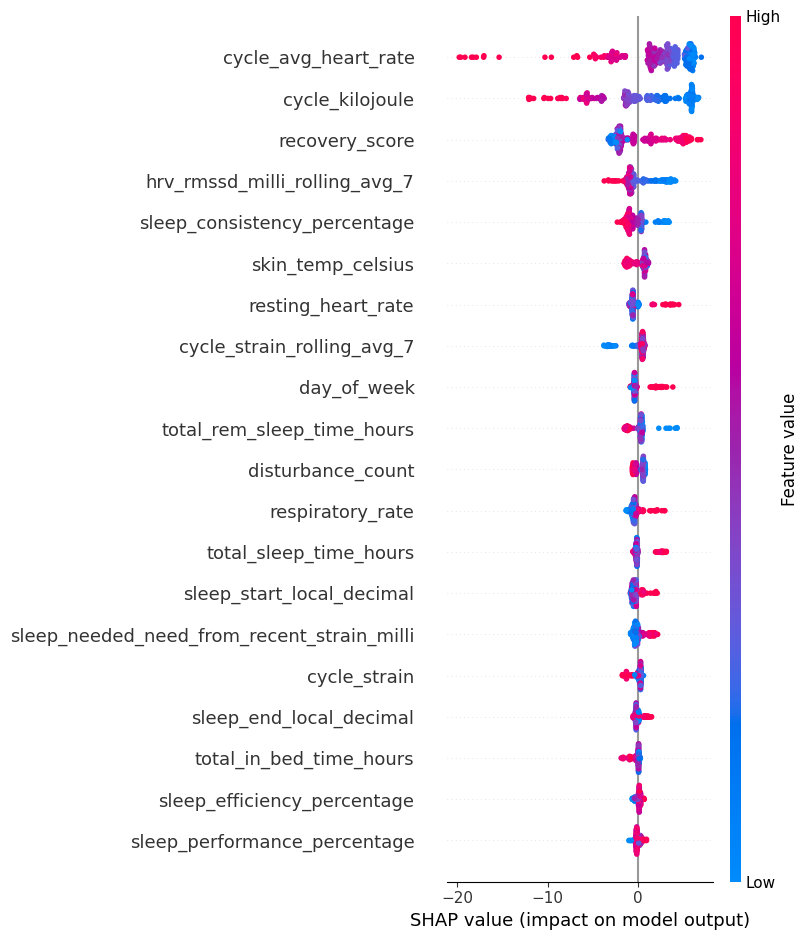

In [38]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [41]:
import pandas as pd
feature_groups = {
    'Physiological': [
        'recovery_score',
        'hrv_rmssd_milli',
        'hrv_rmssd_milli_rolling_avg_7',
        'resting_heart_rate',
        'resting_heart_rate_rolling_avg_7',
        'skin_temp_celsius',
        'respiratory_rate'
    ],
    'Training Load': [
        'cycle_strain',
        'cycle_strain_rolling_avg_7',
        'cycle_avg_heart_rate',
        'cycle_kilojoule',
        'day_of_week'
    ],
    'Sleep': [
        'total_sleep_time_hours',
        'total_rem_sleep_time_hours',
        'total_in_bed_time_hours',
        'sleep_efficiency_percentage',
        'sleep_performance_percentage',
        'sleep_consistency_percentage',
        'sleep_start_local_decimal',
        'sleep_end_local_decimal',
        'disturbance_count',
        'sleep_needed_need_from_recent_strain_milli'
    ]
}
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

group_shap = {}
for group, features in feature_groups.items():
    cols = [f for f in features if f in shap_df.columns]
    group_shap[group] = shap_df[cols].sum(axis=1)

group_shap_df = pd.DataFrame(group_shap)
print(group_shap_df.head())

   Physiological  Training Load     Sleep
0      -2.085119     -25.262428  1.932698
1       8.149848       6.811718  8.108122
2      -0.195075       8.583508  4.585772
3       0.799484       4.760433  4.186006
4      -0.619936       9.175425  3.346942


# 2.5 Summary
## Key findings

**Training load is the dominant driver.** `cycle_avg_heart_rate` and `cycle_kilojoule` are the top two features as high values on both consistently produce large negative SHAP values, pulling tomorrow's predicted recovery down. This is physiologically expected: high cardiovascular demand today requires recovery tomorrow.

**Today's recovery score has strong momentum.** A high recovery score today is positively associated with tomorrow's recovery, suggesting physiological state persists across days.

**7-day HRV trend matters more than today's reading.** `hrv_rmssd_milli_rolling_avg_7` ranks above the single-day HRV value, indicating cumulative autonomic nervous system state is more predictive than daily fluctuation.

**Sleep features have modest individual impact** but contribute positively in aggregate. No single sleep metric dominates, suggesting sleep's effect is distributed across timing, duration, and quality dimensions.

### Limitations

- `resting_heart_rate` and `hrv_rmssd_milli` are highly correlated (r = -0.86). SHAP values for each in isolation should be interpreted cautiously — the model splits their shared signal inconsistently between them.
- Grouped SHAP values (Physiological, Training Load, Sleep) provide a more reliable interpretation than individual feature attribution for correlated features.
- The model is trained on a single individual's data. Physiological relationships are person-specific and the model should not be generalised.

### Future work

- Incorporate HR zone distribution data to enrich training load features beyond average heart rate and kilojoules
- Implement conformal prediction intervals to provide uncertainty estimates alongside point predictions
- Add a validation set split to give unbiased hyperparameter tuning evaluation
- Retrain periodically as new data accumulates in Supabase
